# Stage 2 — Earth interactive network exploration

_Pipeline stage 2 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## From DEM to drainage network

A DEM becomes a **channel network** via flow routing (`FlowObject`), thresholding
flow accumulation to initiate streams (`StreamObject(threshold)`), and **Strahler
pruning** of the finest tips. The stream-initiation threshold is the biggest control
on **drainage density** (Dd = stream length / area) — the quantity we later match
between Earth and Mars.

We extract one basin's network and sweep the threshold to see how Dd responds, with
the three frozen regime thresholds overlaid.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
from channel_heads.dd_calibration import collect_basin_metrics_for_dem
from channel_heads.basin_config import get_basin_config
from channel_heads.regimes import REGIMES
BASIN = 'inyo'
cfg = get_basin_config(BASIN); lat, z_th = cfg['lat'], cfg['z_th']
m = max(collect_basin_metrics_for_dem(dem_path=EXAMPLE_DEMS[BASIN], basin_name=BASIN,
        thresholds_km2=[0.10], z_th=z_th, lat_deg=lat), key=lambda x: x.n_stream_nodes)
print(f'{BASIN}: Dd={m.dd_true_km_km2:.3f} km/km2  length={m.stream_length_km:.0f} km  '
      f'area={m.basin_area_km2:.0f} km2  nodes={m.n_stream_nodes}')

inyo: Dd=1.873 km/km2  length=44 km  area=23 km2  nodes=460


### Drainage density vs stream-initiation threshold

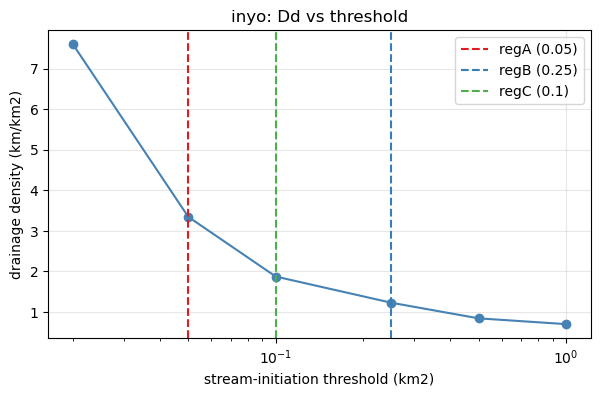

In [3]:
SWEEP = [0.02, 0.05, 0.10, 0.25, 0.5, 1.0]
sweep = collect_basin_metrics_for_dem(dem_path=EXAMPLE_DEMS[BASIN], basin_name=BASIN,
        thresholds_km2=SWEEP, z_th=z_th, lat_deg=lat)
best = {}
for x in sweep:
    if x.threshold_km2 not in best or x.n_stream_nodes > best[x.threshold_km2].n_stream_nodes:
        best[x.threshold_km2] = x
sw = pd.DataFrame([{'threshold_km2': t, 'dd': best[t].dd_true_km_km2} for t in SWEEP if t in best])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sw.threshold_km2, sw.dd, 'o-', color='steelblue')
ax.set_xscale('log'); ax.set_xlabel('stream-initiation threshold (km2)')
ax.set_ylabel('drainage density (km/km2)'); ax.set_title(f'{BASIN}: Dd vs threshold')
for name, r, col in zip(REGIMES, REGIMES.values(), ['#e41a1c', '#377eb8', '#4daf4a']):
    ax.axvline(r.threshold_km2, ls='--', color=col, label=f'{name} ({r.threshold_km2})')
ax.legend(); ax.grid(alpha=0.3); plt.show()

Lower thresholds -> denser networks. The regime thresholds (0.05 / 0.25 / 0.10 km2)
bracket a range of densities chosen so Earth Dd brackets martian Dd. Deep dives:
`notebooks/analysis/02_earth_network_explorer.ipynb`,
`notebooks/diagnostics/dd_threshold_calibration.ipynb`.